In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
a = 7e-6
d = 9e-6
wavelength = 635e-9 # luz roja
theta_inc = 30*np.pi/180
theta_tilt = -12*np.pi/180
num_ord = 4 # número de órdenes que se busca calcular

m = np.linspace(-num_ord, num_ord, num_ord*2+1)

def sinc(x):
  val = np.sinc(np.pi*wavelength*np.sin(x)/a)**2
  return val

# Para encontrar el perfil en 1D (onda con ángulo incidente)

[-0.89822485 -0.79186779 -0.69594519 -0.60718216 -0.52359878 -0.44387752
 -0.3670772  -0.29248579 -0.21953702]
[0.96473039 0.98136769 0.99216634 0.99813905 1.         0.99830659
 0.99352409 0.9860589  0.97627707]


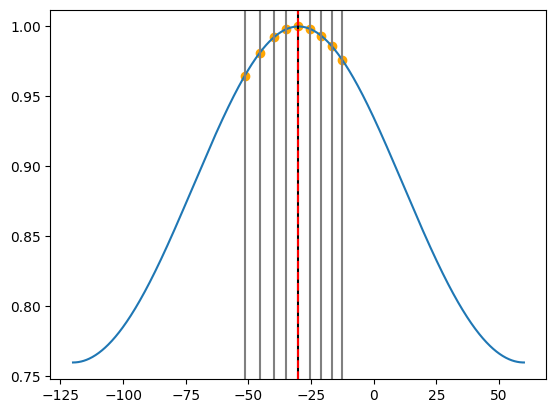

In [3]:
thetax_centrado = np.linspace(-90*np.pi/180, 90*np.pi/180, 1000) # ángulos en los que existe el perfil de intensidad

thetax = thetax_centrado - theta_inc

angulos1D = np.arcsin(m*wavelength/d - np.sin(theta_inc)) # ángulo de los órdenes
sinc1D = sinc(thetax+theta_inc) # perfil de intensidad
intensidades = sinc(angulos1D+theta_inc) # intensidad de los órdenes

print(angulos1D)
print(intensidades)

plt.plot(thetax*180/np.pi, sinc1D)
for i in range(len(m)):
    if m[i] == 0:
      plt.axvline(angulos1D[i]*180/np.pi, color = 'black') # orden 0
    else:
      plt.axvline(angulos1D[i]*180/np.pi, color = 'grey')

plt.scatter(angulos1D*180/np.pi, intensidades, color = 'orange') # posición de los órdenes
plt.axvline(-theta_inc*180/np.pi, linestyle ='--', color = 'red') # centro de la función sinc
plt.show()

# Para encontrar el perfil en 1D (onda con ángulo incidente y tilt)

[-0.89822485 -0.79186779 -0.69594519 -0.60718216 -0.52359878 -0.44387752
 -0.3670772  -0.29248579 -0.21953702]
[0.92135015 0.94478443 0.96345524 0.97790492 0.98850309 0.99553709
 0.99925269 0.99987451 0.9976171 ]


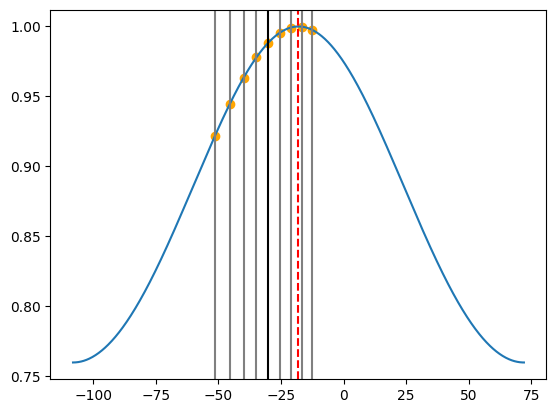

In [4]:
thetax = thetax_centrado - theta_inc - theta_tilt

angulos1D = np.arcsin(m*wavelength/d - np.sin(theta_inc)) # ángulo de los órdenes
sinc1D = sinc(thetax+theta_inc+theta_tilt) # perfil de intensidad
intensidades = sinc(angulos1D + theta_inc + theta_tilt) # intensidad de los órdenes

print(angulos1D)
print(intensidades)

plt.plot(thetax*180/np.pi, sinc1D)
for i in range(len(m)):
    if m[i] == 0:
      plt.axvline(angulos1D[i]*180/np.pi, color = 'black') # orden 0
    else:
      plt.axvline(angulos1D[i]*180/np.pi, color = 'grey')
plt.scatter(angulos1D*180/np.pi, intensidades, color = 'orange') # posición de los órdenes
plt.axvline(-(theta_inc+theta_tilt)*180/np.pi, linestyle ='--', color = 'red') # centro de la función sinc
plt.show()

# Para encontrar el ángulo incidente para blaze conociendo el tilt


El ángulo de incidencia debe ser:  76.27570334631496
[        nan         nan         nan         nan -1.33126216 -1.12182265
 -0.97971303 -0.86297765 -0.76042078]
[       nan        nan        nan        nan 0.98850309 1.
 0.99465165 0.98261608 0.96703758]


/tmp/ipykernel_14504/2093376864.py:9: RuntimeWarning: invalid value encountered in arcsin
  angulos1D = np.arcsin(m*wavelength/d - np.sin(theta_inc)) # ángulo de los órdenes


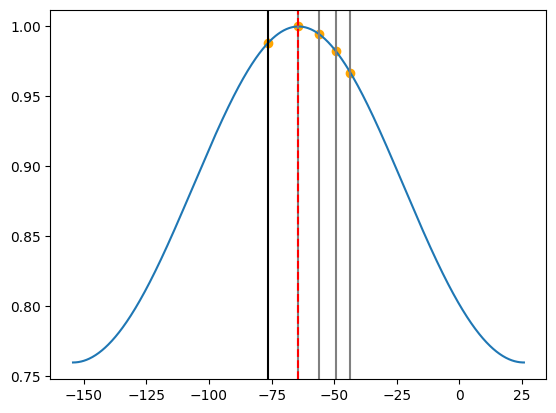

In [5]:
n = 1 # número del orden en el que se quiere el blaze

theta_inc = np.arccos(-n*wavelength/(2*d * np.sin(theta_tilt/2)))-theta_tilt/2

print('El ángulo de incidencia debe ser: ', theta_inc*180/np.pi)

thetax = thetax_centrado - theta_inc - theta_tilt

angulos1D = np.arcsin(m*wavelength/d - np.sin(theta_inc)) # ángulo de los órdenes
sinc1D = sinc(thetax+theta_inc+theta_tilt) # perfil de intensidad
intensidades = sinc(angulos1D + theta_inc + theta_tilt) # intensidad de los órdenes

print(angulos1D)
print(intensidades)

plt.plot(thetax*180/np.pi, sinc1D)
for i in range(len(m)):
    if m[i] == 0:
      plt.axvline(angulos1D[i]*180/np.pi, color = 'black') # orden 0
    else:
      plt.axvline(angulos1D[i]*180/np.pi, color = 'grey')
plt.scatter(angulos1D*180/np.pi, intensidades, color = 'orange') # posición de los órdenes
plt.axvline(-(theta_inc+theta_tilt)*180/np.pi, linestyle ='--', color = 'red') # centro de la función sinc
plt.show()

# Para encontrar el ángulo incidente para blaze conociendo el tilt (con la fórmula equivocada)

-109.88412914326692
[41.15970613 46.77883519 53.06056948 60.43852111 70.11587086         nan
         nan         nan         nan]
[0.7653791  0.77407804 0.78822023 0.81012043 0.84562836        nan
        nan        nan        nan]


/tmp/ipykernel_14504/704779309.py:9: RuntimeWarning: invalid value encountered in arcsin
  angulos1D = np.arcsin(m*wavelength/d - np.sin(theta_inc_teo)) # ángulo de los órdenes


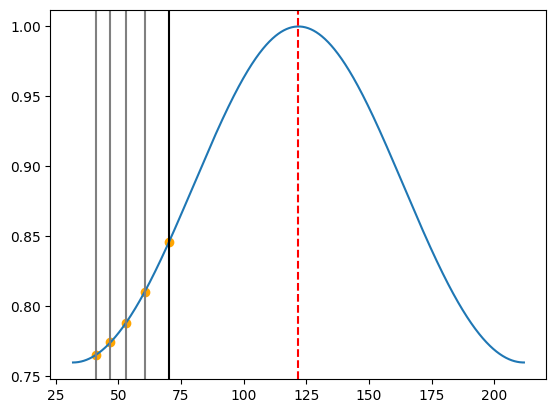

In [6]:
n = 1 # número del orden en el que se quiere el blaze

theta_inc_teo = -np.arccos(n*wavelength/(np.sqrt(2)*d * np.sin(theta_tilt)))+theta_tilt/2

print(theta_inc_teo*180/np.pi)

thetax = thetax_centrado - theta_inc_teo - theta_tilt

angulos1D = np.arcsin(m*wavelength/d - np.sin(theta_inc_teo)) # ángulo de los órdenes
sinc1D = sinc(thetax+theta_inc_teo+theta_tilt) # perfil de intensidad
intensidades = sinc(angulos1D+theta_inc_teo+theta_tilt) # intensidad de los órdenes

print(angulos1D*180/np.pi)
print(intensidades)

plt.plot(thetax*180/np.pi, sinc1D)
for i in range(len(m)):
    if m[i] == 0:
      plt.axvline(angulos1D[i]*180/np.pi, color = 'black') # orden 0
    else:
      plt.axvline(angulos1D[i]*180/np.pi, color = 'grey')
plt.scatter(angulos1D*180/np.pi, intensidades, color = 'orange') # posición de los órdenes
plt.axvline(-(theta_inc_teo+theta_tilt)*180/np.pi, linestyle ='--', color = 'red') # centro de la función sinc
plt.show()